<a href="dependencies/banner.jpeg">
      <img src="dependencies/banner.jpeg" alt="image0" width="100%">
</a>

# Time of flight
Prior to the start of quantum experiments, it is crucial to calibrate the delay between
sending a measurement pulse and beginning the acquisition on the instrument. This delay should be
equal to the time it takes for the readout signal to travel through the fridge and is determined
by the length of the cables. For the experiment a square pulse is played over the output of the
readout line, while a trace acquisition is done. The time at which the pulse is detected on the
acquisition path is determined to be the acquisition delay. This also allows us to set the
NCO propagation delay, which corrects for the phase accumulated during the time of flight.

In [10]:

from dependencies.analysis_utils import TimeOfFlightAnalysis
from xarray import open_dataset

from qblox_scheduler import HardwareAgent, Schedule
from qblox_scheduler.operations import (
    IdlePulse,
    Measure,
    SetClockFrequency,
)

from qblox_scheduler.operations.expressions import DType
from qblox_scheduler.operations.loop_domains import arange

from qblox_sim.simulator import QbloxQutipSimulator

# ## Setup
# The hardware agent manages the connection to the instrument and ensures that pulses and acquisitions happen over the appropriate input and output channels of the Cluster.
# The cell below creates an instance of the `HardwareAgent` based on the hardware- and device-under-test configuration files in the `./dependencies/configs` folder, allowing us to start doing measurements.

In [11]:

# Set up hardware agent, this automatically connects to the instrument
hw_agent = HardwareAgent(
    hardware_configuration="./dependencies/configs/hw_config.json",
    quantum_device_configuration="./dependencies/configs/dut_config.json",
)

# convenience aliases
q0 = hw_agent.quantum_device.get_element("q0")  # Qubits 0 and 2 are measured using QRM-RF + QCM-RF
q2 = hw_agent.quantum_device.get_element("q2")
q3 = hw_agent.quantum_device.get_element("q3")  # Qubit 3 is measured using QRC

cluster = hw_agent.get_clusters()["cluster"]
hw_options = hw_agent.hardware_configuration.hardware_options
qubit = q0

# REFACTORED: Grouped parameters to match qblox_sim.config.SimulationConfig expectations
sim_params = {
    "qubits": {
        qubit.name: {
            "f_q": 5.0e9,
            "f_d": 5.0e9,
            "alpha": -300.0e6,
            "N_q": 3,
            "rabi_freq_per_volt": 10.0e6,
            "T1": 20e-6,
            "T2": 15e-6,
        }
    },
    "resonators": {
        qubit.name: {
            "f_res": qubit.clock_freqs.readout,
            "f_d_res": qubit.clock_freqs.readout,
            "N_res": 5,
            "chi": 1.0e6,
            "kappa": 1e6,
            "rabi_freq_res_per_volt": 10.0e6,
        }
    },
    "acquisition": {
        "noise_sigma": 0.01,
        "cable_delay": 120e-9,
    },
    "dt": 1.0e-9,
}

simulator = QbloxQutipSimulator(sim_params)

# ## Experiment settings

/opt/anaconda3/envs/blox_311/lib/python3.11/site-packages/qblox_scheduler/qblox/hardware_agent.py:485: UserWarning: cluster: Trying to instantiate cluster with ip 'None'.Creating a dummy cluster.
  warnings.warn(


In [12]:

# Pulse settings
pulse_attenuation = 0  # dB
pulse_amplitude = 1  # a.u.
pulse_frequency_detuning = 100e6  # Hz
pulse_duration = 300e-9  # ns
acquisition_duration = 1e-6  # s

repetitions = 1000

# ## Experiment schedule

In [13]:

# Set pulse attenuation
prior_att = hw_options.output_att[f"{qubit.name}:res-{qubit.name}.ro"]
hw_options.output_att[f"{qubit.name}:res-{qubit.name}.ro"] = pulse_attenuation

tof_sched = Schedule("time_of_flight")
tof_sched.add(
    SetClockFrequency(
        clock=qubit.name + ".ro",
        clock_freq_new=qubit.clock_freqs.readout - pulse_frequency_detuning,
    )  # Detune clock 100MHz from expected resonance frequency
)
tof_sched.add(IdlePulse(4e-9))
with tof_sched.loop(arange(0, repetitions, 1, DType.NUMBER)):
    tof_sched.add(
        Measure(
            qubit.name,
            acq_protocol="Trace",
            pulse_amp=pulse_amplitude,
            pulse_duration=pulse_duration,
            acq_duration=acquisition_duration,
            acq_channel="S_21",
            acq_delay=0,
        )
    )

# Execute the experiment simulation
sim_output = simulator.simulate(tof_sched)

if cluster.is_dummy:
    example_data = open_dataset("./dependencies/datasets/time_of_flight.hdf5", engine="h5netcdf")
    tof_data = example_data
else:
    tof_data = sim_output

# Reset attenuation
hw_options.output_att[f"{qubit.name}:res-{qubit.name}.ro"] = prior_att

# ## Analyze the experiment

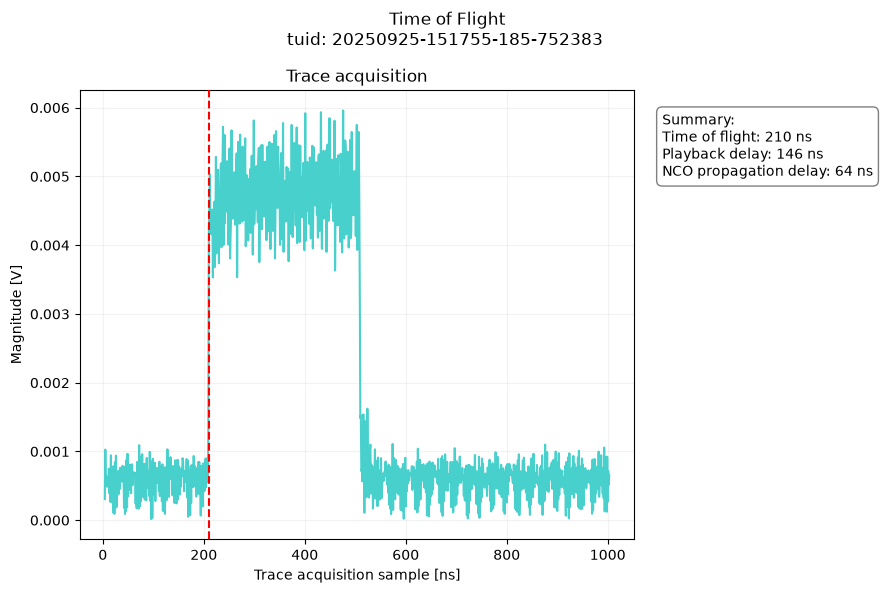

In [14]:

tof_analysis = TimeOfFlightAnalysis(tof_data).run()
tof_analysis.display_figs_mpl()

# ## Post-run

In [15]:

qubit.measure.acq_delay = tof_analysis.quantities_of_interest["tof"]

# Set the NCO propagation delay of the readout line.
cluster.module4.sequencer0.nco_prop_delay_comp_en(True)
cluster.module4.sequencer0.nco_prop_delay_comp(
    tof_analysis.quantities_of_interest["nco_prop_delay"] * 1e9
)

# #### Update the device configuration file
# After measurement, we may store the measured device properties inside a new file to use in future experiments.
# The time-unique identifier ensures that it is easy to find back previously found measurement results.

In [16]:

hw_agent.quantum_device.to_json_file("./dependencies/configs", add_timestamp=True)

'./dependencies/configs/two_flux_tunable_transmons_2026-08-19_15-55-47_UTC.json'